In [52]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd

In [53]:
water = cv.imread("water.jpg")
graywater = cv.cvtColor(water, cv.COLOR_BGR2GRAY)

In [54]:
def ekualisasi(citra): 
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1
    
    # Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(int)
    
    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra) 
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]
    
    return hasil

In [55]:
waterEkualisai = ekualisasi(graywater)

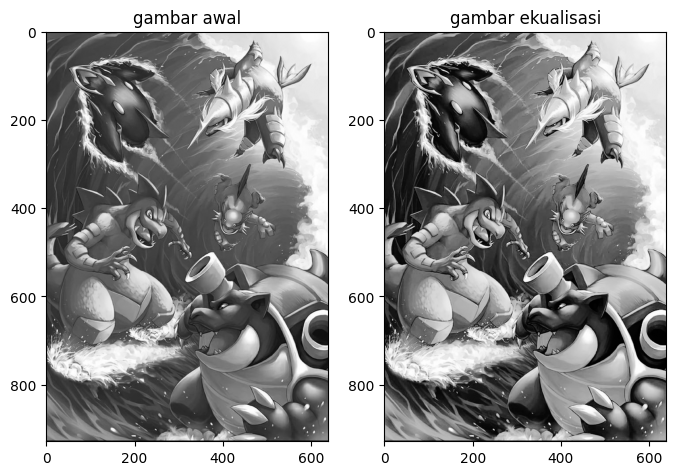

In [56]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("gambar awal")
plt.imshow(graywater, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("gambar ekualisasi")
plt.imshow(waterEkualisai, cmap="gray")

In [57]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1
 
    return histogram 

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

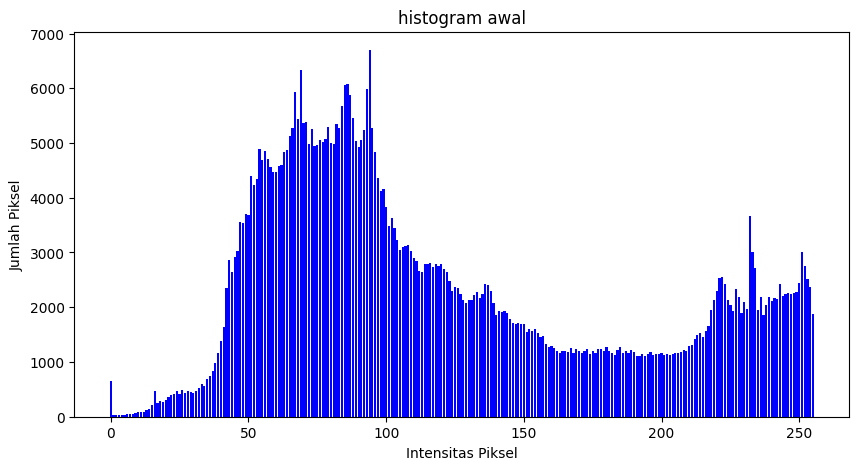

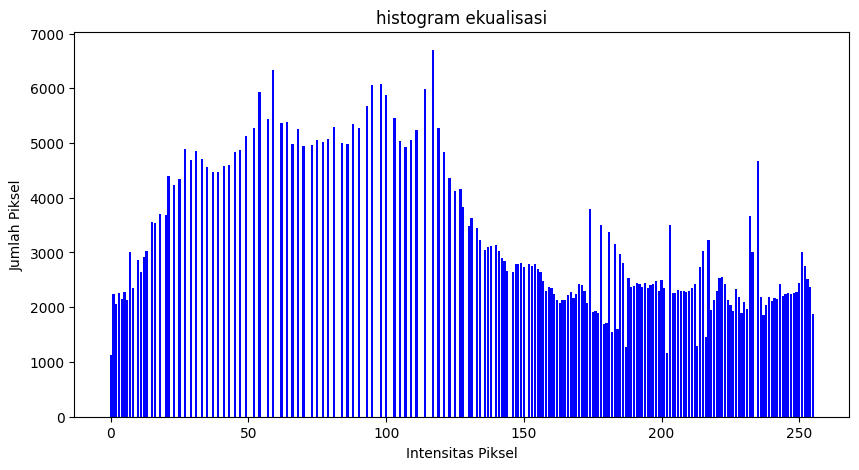

In [58]:
histoAwal = buat_hist(graywater)
plot_histoAwal = plot_histogram(histoAwal, "histogram awal", "blue")
histoEkual = buat_hist(waterEkualisai)
plot_histoEqual = plot_histogram(histoEkual, "histogram ekualisasi", "blue")

In [59]:
target1 = pd.read_csv("target 1.csv")
target2 = pd.read_csv("target 2.csv")

In [ ]:
def tampil_histogram(nama_file):
    # Baca CSV
    data = pd.read_csv(nama_file)

    # Ambil data
    intensity = data["Intensity"]
    sum_pixel = data["Sum of Pixel"]

    # Plot histogram
    plt.figure(figsize=(12, 5))
    plt.bar(intensity, sum_pixel, color = 'green')

    plt.title("Histogram Citra")
    plt.xlabel("Intensity")
    plt.ylabel("Sum of Pixel")

    plt.show()

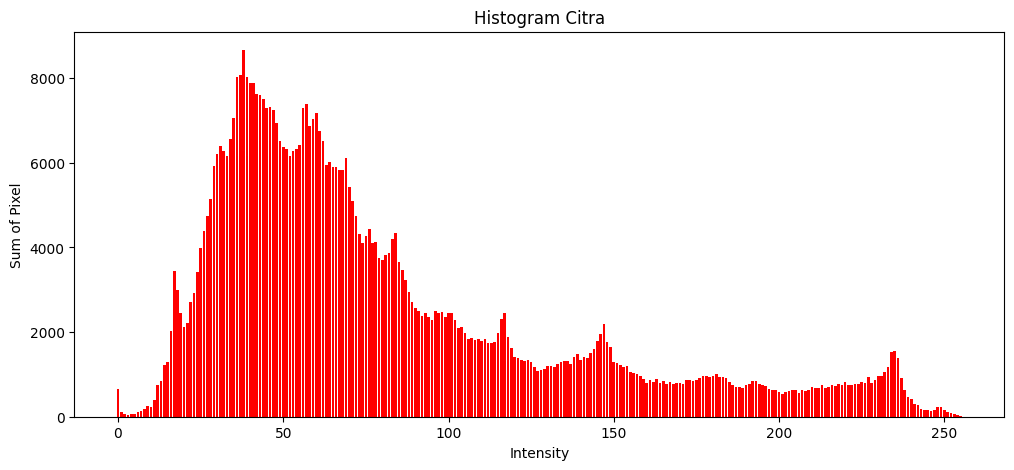

In [77]:
histoTarget1 = tampil_histogram("target 1.csv")